# Supervised Learning - Classification Models

### 1. Import required libraries and Load the Reduced Dataset

In [14]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [3]:
from google.colab import files
uploaded = files.upload()

Saving heart_disease_reduced_dataset.csv to heart_disease_reduced_dataset.csv


In [4]:
df = pd.read_csv('heart_disease_reduced_dataset.csv')

In [5]:
df.head()

,PC13,PC5,PC9,PC2,PC12,PC11,PC15,PC1,HeartDisease
0,0.174570,2.767598,-0.012057,2.262340,0.723671,0.567220,0.386863,0.684512,0
1,-0.340249,0.017665,-0.204954,1.260364,0.444649,-0.771801,-0.856000,3.570333,2
2,-0.313430,-0.740147,-1.090397,-0.713093,-0.406428,0.148344,-0.251198,3.402447,1
3,1.884434,0.317091,-0.740746,0.220787,0.964626,0.203725,-0.828009,-1.651317,0
4,0.631125,1.199871,0.087860,-0.457629,-1.421694,0.696152,0.302566,-2.501824,0


### 2. Split Dataset

In [7]:
X = df.drop('HeartDisease', axis=1)  # PCA features only
y = df['HeartDisease']               # target column

# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### 3. Train Classification Models

In [9]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    train_acc = model.score(X_train, y_train)
    print(f"{name} trained successfully. Training Accuracy: {train_acc:.4f}")

Logistic Regression trained successfully. Training Accuracy: 0.6529
Decision Tree trained successfully. Training Accuracy: 1.0000
Random Forest trained successfully. Training Accuracy: 1.0000
SVM trained successfully. Training Accuracy: 0.7355


### 4. Evaluate Models

--- Logistic Regression ---
Accuracy: 0.6066
Precision: 0.5583
Recall: 0.6066
F1-score: 0.5765


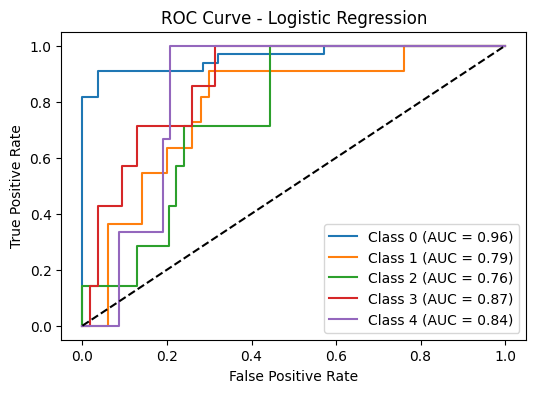

--- Decision Tree ---
Accuracy: 0.4262
Precision: 0.4419
Recall: 0.4262
F1-score: 0.4332


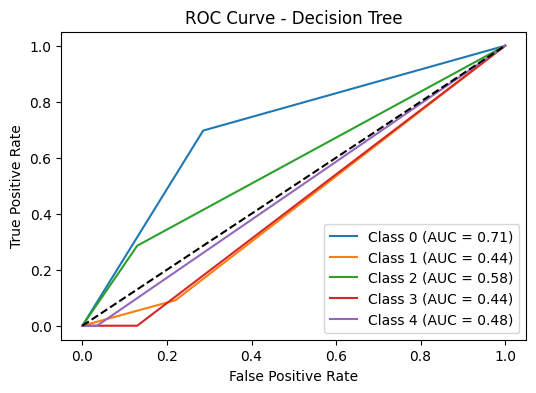

--- Random Forest ---
Accuracy: 0.6230
Precision: 0.5626
Recall: 0.6230
F1-score: 0.5867


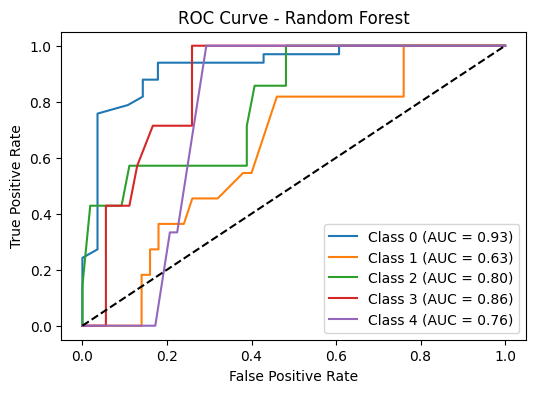

--- SVM ---
Accuracy: 0.6066
Precision: 0.5321
Recall: 0.6066
F1-score: 0.5494


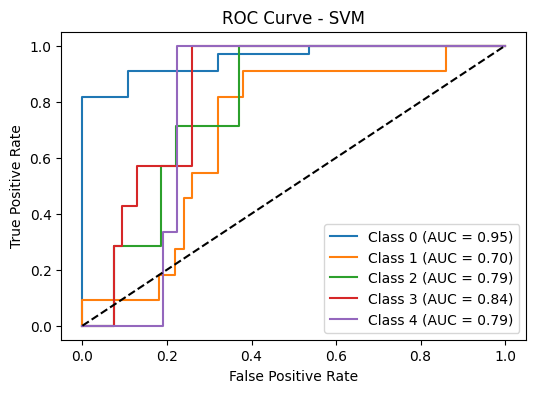

In [16]:
# Binarize target for multiclass ROC
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_bin.shape[1]

def evaluate_model(name, model):
    # Predictions
    y_pred = model.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-score: {f1:.4f}")

    # Multiclass ROC curves
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
        plt.figure(figsize=(6,4))
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            auc = roc_auc_score(y_test_bin[:, i], y_score[:, i])
            plt.plot(fpr, tpr, label=f'Class {i} (AUC = {auc:.2f})')
        plt.plot([0,1],[0,1],'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - {name}')
        plt.legend()
        plt.show()
    else:
        print("ROC/AUC not plotted (model does not support predict_proba).")

# Evaluate all models
for name, model in models.items():
    evaluate_model(name, model)
